# Forecasting Jumlah Penumpang TransJakarta

Project ini bertujuan memprediksi jumlah penumpang TransJakarta per hari menggunakan pendekatan machine learning berbasis data historis.

Model utama yang digunakan adalah Random Forest Regressor. Fitur dibuat dari pola historis jumlah penumpang dan informasi hari dalam satu minggu.


## 1. Import Library

Library yang digunakan untuk manipulasi data, visualisasi, pemodelan machine learning, evaluasi model, dan validasi time series.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Dataset

Dataset dibaca dari file CSV. Pada tahap awal, struktur data diperiksa untuk mengetahui jumlah baris, kolom, tipe data, dan kemungkinan adanya data kosong.


link dataset: https://satudata.jakarta.go.id/open-data/detail?kategori=dataset&page_url=jumlah-penumpang-angkutan-umum-yang-terlayani-perhari&data_no=1

In [3]:
df = pd.read_csv("data/data.csv")

print("Shape:", df.shape)
print("\nKolom:")
print(df.columns.tolist())
print("\nInfo:")
df.info()


Shape: (3402, 4)

Kolom:
['periode_data', 'tanggal', 'jenis_moda', 'jumlah_penumpang_per_hari']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3402 entries, 0 to 3401
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   periode_data               3402 non-null   int64 
 1   tanggal                    3402 non-null   object
 2   jenis_moda                 3402 non-null   object
 3   jumlah_penumpang_per_hari  3402 non-null   object
dtypes: int64(1), object(3)
memory usage: 106.4+ KB


## 3. Exploratory Data Analysis

Dataset memiliki beberapa jenis moda transportasi. Karena project ini berfokus pada TransJakarta, data kemudian difokuskan pada `jenis_moda = transjakarta`.


In [4]:
print("Periode data:")
print(df["periode_data"].min(), "sampai", df["periode_data"].max())

print("\nJenis moda:")
print(df["jenis_moda"].value_counts())

print("\nJumlah data per jenis moda:")
print(df.groupby("jenis_moda").size())


Periode data:
202401 sampai 202504

Jenis moda:
jenis_moda
kapal                   486
transjakarta            486
bus sekolah             486
krl                     486
mrt                     486
lrt                     486
KCI Commuter Bandara    486
Name: count, dtype: int64

Jumlah data per jenis moda:
jenis_moda
KCI Commuter Bandara    486
bus sekolah             486
kapal                   486
krl                     486
lrt                     486
mrt                     486
transjakarta            486
dtype: int64


## 4. Memilih Data TransJakarta

Hanya data dengan jenis moda `transjakarta` yang digunakan untuk proses forecasting.


In [5]:
df = df[df["jenis_moda"] == "transjakarta"].copy()

print("Shape setelah filter transjakarta:", df.shape)


Shape setelah filter transjakarta: (486, 4)


## 5. Data Preprocessing

Kolom tanggal dikonversi menjadi tipe datetime agar dapat digunakan untuk pengurutan dan pembuatan fitur waktu.

Kolom jumlah penumpang dikonversi menjadi numerik. Nilai yang tidak dapat dikonversi akan menjadi `NaN`.


In [6]:
df["tanggal"] = pd.to_datetime(df["tanggal"])

df["jumlah_penumpang_per_hari"] = pd.to_numeric(
    df["jumlah_penumpang_per_hari"],
    errors="coerce"
)

print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 486 entries, 5 to 3294
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   periode_data               486 non-null    int64         
 1   tanggal                    486 non-null    datetime64[ns]
 2   jenis_moda                 486 non-null    object        
 3   jumlah_penumpang_per_hari  485 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 19.0+ KB
None


## 6. Penanganan Missing Value

Nilai target yang kosong tidak dapat digunakan untuk proses training. Karena nilai aktualnya tidak tersedia pada dataset, baris tersebut dihapus.


In [7]:
print("Missing value:")
print(df.isna().sum())

df = df.dropna(
    subset=["jumlah_penumpang_per_hari"]
).copy()

print("\nShape setelah menghapus target yang kosong:", df.shape)


Missing value:
periode_data                 0
tanggal                      0
jenis_moda                   0
jumlah_penumpang_per_hari    1
dtype: int64

Shape setelah menghapus target yang kosong: (485, 4)


## 7. Pengurutan Data Berdasarkan Waktu

Data diurutkan berdasarkan tanggal untuk memastikan urutan temporal tetap benar sebelum membuat fitur lag dan melakukan pembagian training dan testing.


In [8]:
df = df.sort_values("tanggal").reset_index(drop=True)

print("Rentang tanggal:")
print(df["tanggal"].min(), "sampai", df["tanggal"].max())

print("\nJumlah duplikat tanggal:")
print(df["tanggal"].duplicated().sum())

print("\nPerbedaan antar tanggal:")
print(df["tanggal"].diff().value_counts())


Rentang tanggal:
2024-01-01 00:00:00 sampai 2025-04-30 00:00:00

Jumlah duplikat tanggal:
0

Perbedaan antar tanggal:
tanggal
1 days    483
2 days      1
Name: count, dtype: int64


## 8. Feature Engineering

Fitur lag digunakan untuk memberikan informasi mengenai jumlah penumpang pada periode sebelumnya.

- `lag_1`: jumlah penumpang pada data sebelumnya.
- `lag_7`: jumlah penumpang tujuh periode sebelumnya.
- `lag_14`: jumlah penumpang empat belas periode sebelumnya.
- `lag_28`: jumlah penumpang dua puluh delapan periode sebelumnya.

Selain itu, digunakan statistik rolling tujuh periode untuk merangkum kondisi historis terbaru.

`shift(1)` digunakan sebelum rolling agar nilai pada hari yang sedang diprediksi tidak ikut masuk ke dalam perhitungan fitur.


In [9]:
df["lag_1"] = df["jumlah_penumpang_per_hari"].shift(1)
df["lag_7"] = df["jumlah_penumpang_per_hari"].shift(7)
df["lag_14"] = df["jumlah_penumpang_per_hari"].shift(14)
df["lag_28"] = df["jumlah_penumpang_per_hari"].shift(28)

df["rolling_mean_7"] = (
    df["jumlah_penumpang_per_hari"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

df["rolling_std_7"] = (
    df["jumlah_penumpang_per_hari"]
    .shift(1)
    .rolling(window=7)
    .std()
)

df["day_of_week"] = df["tanggal"].dt.dayofweek


## 9. Menyiapkan Dataset Modeling

Baris yang belum memiliki nilai lengkap pada seluruh fitur dihapus.

Fitur yang digunakan:

`lag_1`, `lag_7`, `lag_14`, `lag_28`, `rolling_mean_7`, `rolling_std_7`, dan `day_of_week`.

Target yang diprediksi adalah `jumlah_penumpang_per_hari`.


In [10]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week"
]

df = df.dropna(subset=features).copy()

X = df[features]
y = df["jumlah_penumpang_per_hari"]

print("Jumlah data:", len(df))
print("\nFeatures:")
print(features)


Jumlah data: 457

Features:
['lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'day_of_week']


## 10. Train-Test Split Berbasis Waktu

Karena data merupakan time series, pembagian data dilakukan berdasarkan urutan waktu.

80% data awal digunakan sebagai training set dan 20% data terakhir digunakan sebagai test set.

Pendekatan ini mencegah data masa depan digunakan untuk melatih model sebelum periode tersebut terjadi.


In [11]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Data training:", len(X_train))
print("Data testing :", len(X_test))

print(
    "\nPeriode training:",
    df["tanggal"].iloc[0],
    "sampai",
    df["tanggal"].iloc[split_index - 1]
)

print(
    "Periode testing :",
    df["tanggal"].iloc[split_index],
    "sampai",
    df["tanggal"].iloc[-1]
)


Data training: 365
Data testing : 92

Periode training: 2024-01-29 00:00:00 sampai 2025-01-28 00:00:00
Periode testing : 2025-01-29 00:00:00 sampai 2025-04-30 00:00:00


## 11. Baseline Model: Linear Regression

Linear Regression digunakan sebagai baseline. Tujuannya adalah memperoleh titik pembanding untuk melihat apakah model Random Forest mampu memberikan performa yang lebih baik daripada hubungan linear sederhana.


In [12]:
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"MAE  : {mae_lr:,.2f}")
print(f"RMSE : {rmse_lr:,.2f}")
print(f"R²   : {r2_lr:.4f}")


Linear Regression
MAE  : 111,341.23
RMSE : 154,174.73
R²   : 0.6688


## 12. Random Forest Regressor

Random Forest digunakan sebagai model utama. Model ini terdiri dari banyak decision tree dan menggabungkan hasil prediksi dari tree tersebut.

Konfigurasi awal menggunakan 200 tree.


In [13]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")


Random Forest
MAE  : 76,522.28
RMSE : 128,156.54
R²   : 0.7711


## 13. Feature Importance

Feature importance digunakan untuk melihat fitur mana yang paling banyak digunakan oleh Random Forest dalam proses pengambilan keputusan.

Nilai importance menunjukkan kontribusi fitur terhadap struktur model, bukan hubungan sebab-akibat.


In [14]:
feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)


day_of_week       0.578727
lag_1             0.176161
rolling_mean_7    0.059059
lag_28            0.056902
lag_7             0.052973
lag_14            0.042615
rolling_std_7     0.033563
dtype: float64


## 14. Visualisasi Aktual vs Prediksi

Grafik berikut membandingkan jumlah penumpang aktual dengan hasil prediksi Random Forest pada periode testing.


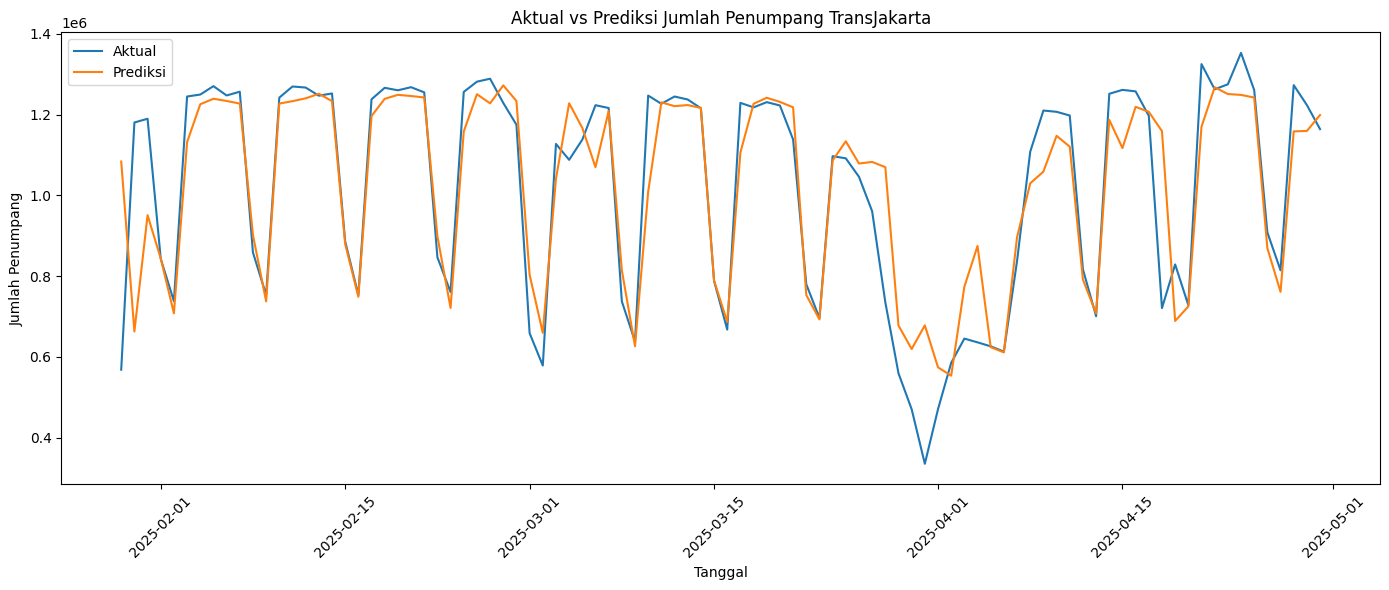

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["tanggal"].iloc[split_index:],
    y_test,
    label="Aktual"
)

plt.plot(
    df["tanggal"].iloc[split_index:],
    y_pred_rf,
    label="Prediksi"
)

plt.xlabel("Tanggal")
plt.ylabel("Jumlah Penumpang")
plt.title("Aktual vs Prediksi Jumlah Penumpang TransJakarta")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 15. Hyperparameter Tuning

GridSearchCV digunakan untuk mencari kombinasi hyperparameter Random Forest yang memberikan performa validasi terbaik.

Cross-validation menggunakan `TimeSeriesSplit` agar urutan waktu tetap dipertahankan.

MAE digunakan sebagai metrik scoring karena menunjukkan rata-rata besar kesalahan prediksi dalam satuan jumlah penumpang.


In [16]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

Best CV MAE:
96405.25623402942


## 16. Final Random Forest

Model final dibuat menggunakan hyperparameter terbaik yang diperoleh dari proses tuning.


In [17]:
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=1
)

best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)


## 17. Evaluasi Model Final

Model final dievaluasi menggunakan data testing yang tidak digunakan selama proses training dan tuning.

Metrik yang digunakan adalah MAE, RMSE, dan R².


In [18]:
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("Random Forest setelah tuning")
print(f"MAE  : {mae_best:,.2f}")
print(f"RMSE : {rmse_best:,.2f}")
print(f"R²   : {r2_best:.4f}")


Random Forest setelah tuning
MAE  : 78,729.61
RMSE : 130,341.02
R²   : 0.7633


## 18. Time Series Cross-Validation Model Final

Cross-validation digunakan untuk melihat konsistensi performa model pada beberapa periode validasi.

Berbeda dengan test set, validation set pada setiap fold berasal dari bagian waktu yang berbeda. Data testing akhir tetap dipisahkan untuk evaluasi final.


In [19]:
cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_train),
    start=1
):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=1
    )

    model.fit(X_tr, y_tr)

    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)

    cv_results.append([fold, mae, rmse, r2])

    print(
        f"Fold {fold}: "
        f"MAE={mae:,.2f}, "
        f"RMSE={rmse:,.2f}, "
        f"R²={r2:.4f}"
    )

cv_results = pd.DataFrame(
    cv_results,
    columns=["Fold", "MAE", "RMSE", "R2"]
)

print("\nRata-rata Cross-Validation:")
print(f"MAE  : {cv_results['MAE'].mean():,.2f}")
print(f"RMSE : {cv_results['RMSE'].mean():,.2f}")
print(f"R²   : {cv_results['R2'].mean():.4f}")


Fold 1: MAE=149,386.92, RMSE=223,905.51, R²=0.2827
Fold 2: MAE=136,063.20, RMSE=162,147.07, R²=0.4639
Fold 3: MAE=58,303.12, RMSE=104,567.29, R²=0.7658
Fold 4: MAE=56,285.78, RMSE=130,703.32, R²=0.6697
Fold 5: MAE=87,524.07, RMSE=134,999.06, R²=0.6345

Rata-rata Cross-Validation:
MAE  : 97,512.62
RMSE : 151,264.45
R²   : 0.5633


## 19. Ringkasan Hasil

Model final menggunakan Random Forest Regressor dengan tujuh fitur berbasis histori dan kalender.

Hasil test set yang diperoleh:

- MAE: sekitar 78 ribu penumpang per hari.
- RMSE: sekitar 130 ribu penumpang per hari.
- R²: sekitar 0,76.

Hasil tersebut menunjukkan bahwa model mampu menangkap sebagian besar pola variasi jumlah penumpang pada periode testing. Namun, hasil cross-validation menunjukkan bahwa performa model dapat berubah antarperiode, sehingga model tidak dianggap sebagai model yang sempurna atau berlaku sama untuk seluruh periode waktu.


In [20]:
print("===== RINGKASAN PROJECT =====")
print("Model akhir: Random Forest Regressor")

print("\nFeatures:")
for feature in features:
    print(f"- {feature}")

print("\nTest Set:")
print(f"MAE  : {mae_best:,.2f}")
print(f"RMSE : {rmse_best:,.2f}")
print(f"R²   : {r2_best:.4f}")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(f"{-grid_search.best_score_:,.2f}")

print("\nAverage Time Series CV:")
print(f"MAE  : {cv_results['MAE'].mean():,.2f}")
print(f"RMSE : {cv_results['RMSE'].mean():,.2f}")
print(f"R²   : {cv_results['R2'].mean():.4f}")


===== RINGKASAN PROJECT =====
Model akhir: Random Forest Regressor

Features:
- lag_1
- lag_7
- lag_14
- lag_28
- rolling_mean_7
- rolling_std_7
- day_of_week

Test Set:
MAE  : 78,729.61
RMSE : 130,341.02
R²   : 0.7633

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

Best CV MAE:
96,405.26

Average Time Series CV:
MAE  : 97,512.62
RMSE : 151,264.45
R²   : 0.5633
